# AstroLongevity Data Pipeline

**NASA Space Apps Challenge 2026 | Team Astrophel | Labony Sur, Aupurba Sarker**

This notebook retrieves real differential expression data from the NASA Open Science Data Repository (OSDR), validates it through three fail-closed quality control gates, performs PCA, cross-study concordance analysis, cross-species validation against published literature, and saves every output to Google Drive.

No data is generated, simulated, or hardcoded. Every number shown comes directly from NASA OSDR files or peer-reviewed published literature with explicit citations.

In [1]:
# Cell 1: Environment setup and Google Drive mount

import requests
import pandas as pd
import numpy as np
import json
from google.colab import drive
import shutil
import time
import logging
import sys
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True,
    handlers=[logging.StreamHandler(sys.stdout)]
)
logger = logging.getLogger(__name__)

drive.mount("/content/drive")

DRIVE_PATH = "/content/drive/MyDrive/AstroLongevity_Data_Final"
LOCAL_CACHE = "nasa_data"
os.makedirs(LOCAL_CACHE, exist_ok=True)
os.makedirs(DRIVE_PATH, exist_ok=True)

logger.info("Environment ready. Google Drive mounted at /content/drive.")
logger.info(f"Output directory: {DRIVE_PATH}")

2026-08-29 21:09:46,597 - INFO - Environment ready. Google Drive mounted at /content/drive.


2026-08-29 21:09:46,598 - INFO - Output directory: AstroLongevity_Data_Final


In [2]:
# Cell 2: Core pipeline functions
# get_study_files     - fetches the file manifest from NASA OSDR REST API
# download_study_file - selects the correct file by dataset type and streams it to disk
# validate_dataframe  - three fail-closed quality control gates

import requests
import pandas as pd
import numpy as np
import json
import os
import shutil
import time
import logging
import sys
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def get_study_files(osd_id):
    numeric_id = osd_id.split("-")[-1]
    api_url = f"https://osdr.nasa.gov/osdr/data/osd/files/{numeric_id}"
    response = requests.get(api_url, timeout=30)
    if response.status_code != 200:
        raise requests.exceptions.HTTPError(
            f"NASA OSDR API returned HTTP {response.status_code} for {osd_id}."
        )
    resp_data = response.json()
    try:
        file_list = resp_data["studies"][osd_id]["study_files"]
    except KeyError:
        raise ValueError(f"Unexpected JSON structure returned for {osd_id}.")
    if not file_list:
        raise ValueError(f"No files found in the manifest for {osd_id}.")
    return file_list

def download_study_file(osd_id, file_list):
    if osd_id == "OSD-21":
        keywords = ["normalized_intensities"]
    else:
        # Download both to get counts for PCA and stats for concordance
        keywords = ["normalized_counts", "differential_expression"]

    dfs = []
    for keyword in keywords:
        target_file = None
        target_url = None

        for file_info in file_list:
            fname = file_info.get("file_name", "").lower()
            # prefer rRNArm
            if fname.endswith(".csv") and keyword.lower() in fname and "rrnarm" in fname and "unnormalized" not in fname:
                target_file = file_info.get("file_name")
                remote = file_info.get("remote_url", "")
                if not remote.startswith("http"):
                    remote = "https://osdr.nasa.gov" + remote
                target_url = remote
                break

        if target_file is None:
            for file_info in file_list:
                fname = file_info.get("file_name", "").lower()
                if fname.endswith(".csv") and keyword.lower() in fname and "unnormalized" not in fname:
                    target_file = file_info.get("file_name")
                    remote = file_info.get("remote_url", "")
                    if not remote.startswith("http"):
                        remote = "https://osdr.nasa.gov" + remote
                    target_url = remote
                    break

        if target_file is None:
            raise FileNotFoundError(f"Could not find a CSV file containing '{keyword}'.")

        save_path = os.path.join(LOCAL_CACHE, f"{osd_id}_{target_file}")
        logger.info(f"Downloading: {target_file}  ->  {save_path}")

        # Download if not already downloaded
        if not os.path.exists(save_path):
            with requests.get(target_url, stream=True, timeout=120) as r:
                if r.status_code != 200:
                    raise requests.exceptions.HTTPError(f"HTTP {r.status_code}.")
                with open(save_path, "wb") as f:
                    for chunk in r.iter_content(chunk_size=8192):
                        f.write(chunk)

        sep = "\t" if save_path.lower().endswith((".tsv", ".txt")) else ","
        df = pd.read_csv(save_path, sep=sep, low_memory=False)
        dfs.append(df)

    if len(dfs) == 1:
        return dfs[0], ""
    else:
        # Merge normalized counts and differential expression
        df_counts = dfs[0]
        df_de = dfs[1]
        df_merged = pd.merge(df_counts, df_de, left_on=df_counts.columns[0], right_on="ENSEMBL", suffixes=("_count", "_de"))
        return df_merged, ""

def validate_dataframe(df, dataset_name):
    row_count, col_count = df.shape
    if row_count <= 1000:
        raise ValueError(f"QC FAIL [{dataset_name}] Gate 1")
    first_col = df.columns[0]
    null_count = df[first_col].isna().sum()
    if null_count > 0:
        raise ValueError(f"QC FAIL [{dataset_name}] Gate 2")
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) == 0:
        raise ValueError(f"QC FAIL [{dataset_name}] Gate 3")
    logger.info(f"QC COMPLETE [{dataset_name}]: All three gates passed.")



In [3]:
# Cell 3: Download all three NASA OSDR datasets and run quality control
#
# OSD-21  : microarray, normalized intensities, 230,000+ probes
# OSD-101 : RNA-Seq normalized counts, 23,257 genes (Rodent Research 4)
# OSD-104 : RNA-Seq normalized counts, 22,437 genes (Rodent Research 1)
#
# All files are saved to LOCAL_CACHE on the Colab instance disk first,
# then copied to Google Drive at the end of this cell.

DATASETS = ["OSD-21", "OSD-101", "OSD-104"]
dataframes = {}
download_times = {}

for study_id in DATASETS:
    logger.info(f"=== Starting {study_id} ===")
    t_start = time.time()
    try:
        file_list = get_study_files(study_id)
        logger.info(f"Manifest retrieved: {len(file_list)} total files listed for {study_id}.")

        df, local_path = download_study_file(study_id, file_list)

        # OSD-21 post-load cleanup:
        # The microarray file contains many annotation columns (SYMBOL, GENENAME, etc.).
        # We keep only rows where SYMBOL is not null and retain all numeric intensity columns.
        if study_id == "OSD-21":
            if "SYMBOL" not in df.columns:
                raise ValueError("OSD-21: Expected 'SYMBOL' column not found after load.")
            before = len(df)
            df = df.dropna(subset=["SYMBOL"]).copy()
            after = len(df)
            logger.info(f"OSD-21 cleanup: Removed {before - after} probes with null SYMBOL. {after} probes retained.")

        validate_dataframe(df, study_id)
        dataframes[study_id] = df

        elapsed = time.time() - t_start
        download_times[study_id] = round(elapsed, 1)
        logger.info(f"=== {study_id} complete in {elapsed:.1f}s ===")

    except Exception as err:
        logger.error(f"FAILED for {study_id}: {err}")

# Copy everything from local cache to Google Drive
shutil.copytree(LOCAL_CACHE, DRIVE_PATH, dirs_exist_ok=True)
logger.info(f"All downloaded files saved to Google Drive: {DRIVE_PATH}")

# Summary
print("\nDownload summary:")
for sid in DATASETS:
    if sid in dataframes:
        df = dataframes[sid]
        size_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
        print(f"  {sid}: {df.shape[0]} rows x {df.shape[1]} cols  |  {size_mb:.1f} MB in memory  |  {download_times.get(sid, '?')}s")
    else:
        print(f"  {sid}: FAILED - see error above")

2026-08-29 21:09:46,618 - INFO - === Starting OSD-21 ===


2026-08-29 21:09:48,236 - INFO - Manifest retrieved: 32 total files listed for OSD-21.


2026-08-29 21:09:48,236 - INFO - Downloading: GLDS-21_array_normalized_intensities_probe_GLmicroarray.csv  ->  nasa_data\OSD-21_GLDS-21_array_normalized_intensities_probe_GLmicroarray.csv


2026-08-29 21:09:50,414 - INFO - OSD-21 cleanup: Removed 40306 probes with null SYMBOL. 209652 probes retained.


2026-08-29 21:09:50,420 - INFO - QC COMPLETE [OSD-21]: All three gates passed.


...

2026-08-29 21:10:11,512 - INFO - QC COMPLETE [OSD-104]: All three gates passed.


2026-08-29 21:10:11,512 - INFO - === OSD-104 complete in 8.3s ===


2026-08-29 21:10:11,657 - INFO - All downloaded files saved to Google Drive: AstroLongevity_Data_Final



Download summary:


  OSD-21: 209652 rows x 33 cols  |  238.0 MB in memory  |  3.8s
  OSD-101: 23257 rows x 47 cols  |  23.0 MB in memory  |  12.8s
  OSD-104: 22437 rows x 47 cols  |  22.4 MB in memory  |  8.3s


In [4]:
# Cell 4: Data Ingestion Verification
#
# Prove successful data ingestion by displaying standard Pandas data summaries.

print("DATA INGESTION VERIFICATION")
print("-" * 60)

# --- OSD-104 ---
print("\n[OSD-104] Data Overview")
df104 = dataframes.get("OSD-104")
if df104 is not None:
    print(f"  Gene count    : {len(df104)}")
    display(df104.head())
    display(df104.describe())
else:
    print("  Status        : FILE NOT FOUND IN MEMORY")

print("\n" + "-" * 60)
print("Ingestion check complete.")

DATA INGESTION VERIFICATION
------------------------------------------------------------

[OSD-104] Data Overview
  Gene count    : 22437


,Unnamed: 0,Mmus_C57-6J_SLS_GC_Rep1_M33_count,Mmus_C57-6J_SLS_GC_Rep2_M34_count,Mmus_C57-6J_SLS_GC_Rep3_M35_count,Mmus_C57-6J_SLS_GC_Rep4_M36_count,Mmus_C57-6J_SLS_GC_Rep5_M37_count,Mmus_C57-6J_SLS_GC_Rep6_M38_count,Mmus_C57-6J_SLS_FLT_Rep1_M23_count,Mmus_C57-6J_SLS_FLT_Rep2_M24_count,Mmus_C57-6J_SLS_FLT_Rep3_M25_count,...,Stat_(Space Flight)v(Ground Control),P.value_(Space Flight)v(Ground Control),Adj.p.value_(Space Flight)v(Ground Control),All.mean,All.stdev,LRT.p.value,Group.Mean_(Ground Control),Group.Stdev_(Ground Control),Group.Mean_(Space Flight),Group.Stdev_(Space Flight)
0,ENSMUSG00000000001,1006.549539,917.177689,962.585436,856.438346,858.164317,903.862859,1019.909395,849.477852,818.014898,...,-0.800578,4.233762e-01,6.222426e-01,902.044568,65.307673,6.201814e-01,918.463031,58.987852,885.626105,72.502950
1,ENSMUSG00000000028,122.780510,120.787163,108.787967,110.924372,129.468089,136.082247,105.181106,161.957778,89.083210,...,0.449427,6.531238e-01,8.014667e-01,125.373582,21.778014,7.970836e-01,122.471725,10.504429,128.275440,30.213693
2,ENSMUSG00000000031,122071.523633,106248.185231,114543.025721,113837.456398,105668.079907,117319.964828,80123.454079,75933.263279,84141.573694,...,-6.725307,1.752231e-11,5.566505e-10,94861.999851,20916.735887,6.458088e-10,113282.372620,6370.336418,76441.627082,10372.856080
3,ENSMUSG00000000037,19.316005,11.721741,7.417855,5.255145,2.642104,14.404212,7.410470,8.733346,7.999338,...,-0.282752,7.773669e-01,8.813078e-01,10.734182,4.463663,8.739127e-01,11.126177,6.202800,10.342188,2.233811
4,ENSMUSG00000000049,19.454152,11.728960,9.078504,6.609842,12.349941,10.031747,10.931802,11.192994,19.065907,...,2.156958,3.100892e-02,9.888350e-02,17.991736,12.749774,1.016855e-01,12.542191,4.380999,23.441281,16.344956


,Mmus_C57-6J_SLS_GC_Rep1_M33_count,Mmus_C57-6J_SLS_GC_Rep2_M34_count,Mmus_C57-6J_SLS_GC_Rep3_M35_count,Mmus_C57-6J_SLS_GC_Rep4_M36_count,Mmus_C57-6J_SLS_GC_Rep5_M37_count,Mmus_C57-6J_SLS_GC_Rep6_M38_count,Mmus_C57-6J_SLS_FLT_Rep1_M23_count,Mmus_C57-6J_SLS_FLT_Rep2_M24_count,Mmus_C57-6J_SLS_FLT_Rep3_M25_count,Mmus_C57-6J_SLS_FLT_Rep4_M26_count,...,Stat_(Space Flight)v(Ground Control),P.value_(Space Flight)v(Ground Control),Adj.p.value_(Space Flight)v(Ground Control),All.mean,All.stdev,LRT.p.value,Group.Mean_(Ground Control),Group.Stdev_(Ground Control),Group.Mean_(Space Flight),Group.Stdev_(Space Flight)
count,2.243700e+04,2.243700e+04,2.243700e+04,2.243700e+04,2.243700e+04,2.243700e+04,2.243700e+04,2.243700e+04,2.243700e+04,2.243700e+04,...,22437.000000,2.234700e+04,1.931500e+04,2.243700e+04,2.243700e+04,1.931500e+04,2.243700e+04,22437.000000,2.243700e+04,2.243700e+04
mean,2.596674e+03,2.691792e+03,2.765723e+03,2.669761e+03,2.658764e+03,2.595884e+03,2.790743e+03,2.761182e+03,2.676850e+03,2.719699e+03,...,0.058254,3.243075e-01,3.975649e-01,2.695726e+03,3.955598e+02,3.939536e-01,2.664100e+03,199.631769,2.727353e+03,2.934062e+02
std,4.830834e+04,4.898540e+04,5.166054e+04,4.856337e+04,4.595701e+04,4.532515e+04,6.472956e+04,6.443336e+04,5.527019e+04,5.997709e+04,...,2.555668,3.175747e-01,3.411832e-01,5.317415e+04,1.043218e+04,3.366410e-01,4.808371e+04,3300.160813,5.891202e+04,8.690474e+03
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-21.886828,3.468252e-106,6.698928e-102,1.485955e+00,4.788793e-01,3.012439e-96,1.000000e+00,0.000000,1.000000e+00,0.000000e+00
25%,5.868335e+00,5.044872e+00,5.423282e+00,6.830338e+00,5.948912e+00,5.925155e+00,7.042993e+00,7.245133e+00,7.056172e+00,6.897500e+00,...,-1.056403,2.100105e-02,4.429080e-02,7.986892e+00,4.128300e+00,4.447319e-02,7.037770e+00,3.186245,8.610447e+00,3.999514e+00
50%,1.045872e+02,9.758852e+01,9.943519e+01,1.062051e+02,1.020181e+02,1.039685e+02,1.079753e+02,1.084629e+02,1.077415e+02,1.028244e+02,...,0.190829,2.257320e-01,3.452626e-01,1.073903e+02,2.325676e+01,3.435213e-01,1.036836e+02,17.017326,1.068211e+02,2.029518e+01
75%,9.224755e+02,9.346738e+02,9.172989e+02,9.103245e+02,9.221351e+02,9.176126e+02,9.047129e+02,9.014150e+02,9.043930e+02,9.095241e+02,...,1.338571,5.884145e-01,7.183769e-01,9.193801e+02,9.966665e+01,7.116594e-01,9.265755e+02,69.196228,9.124462e+02,8.320760e+01
max,5.960398e+06,5.962802e+06,6.262531e+06,5.777752e+06,5.389350e+06,5.411292e+06,8.675463e+06,8.677531e+06,7.199031e+06,7.936285e+06,...,17.965913,9.999745e-01,9.999745e-01,6.781810e+06,1.337084e+06,9.992545e-01,5.794022e+06,342396.032939,7.769599e+06,1.214153e+06



------------------------------------------------------------
Ingestion check complete.


In [5]:
# Cell 5: Computational performance benchmark
#
# Measures actual wall-clock time and peak memory usage for each pipeline stage.
# All measurements are from the live run on this Colab instance, not estimated.

import tracemalloc

print("COMPUTATIONAL BENCHMARK")
print("-" * 60)
print(f"Runtime: Google Colab (see instance spec in Runtime menu)")
print()

bench_results = []

# --- Benchmark: API manifest fetch (OSD-104 as representative) ---
tracemalloc.start()
t0 = time.time()
_ = get_study_files("OSD-104")
t_api = time.time() - t0
_, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
bench_results.append({"Stage": "API manifest fetch (OSD-104)", "Time_s": round(t_api, 2), "Peak_RAM_MB": round(peak / 1e6, 1)})
print(f"  API fetch        : {t_api:.2f}s")

# --- Benchmark: CSV parse from disk (OSD-104) ---
osd104_local = os.path.join(LOCAL_CACHE, "OSD-104_GLDS-104_rna_seq_Normalized_Counts_rRNArm_GLbulkRNAseq.csv")
if os.path.exists(osd104_local):
    tracemalloc.start()
    t0 = time.time()
    df_bench = pd.read_csv(osd104_local, low_memory=False)
    t_parse = time.time() - t0
    _, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
    bench_results.append({"Stage": "CSV parse into DataFrame (OSD-104)", "Time_s": round(t_parse, 2), "Peak_RAM_MB": round(peak / 1e6, 1)})
    print(f"  CSV parse        : {t_parse:.2f}s")

    # --- Benchmark: QC gates ---
    tracemalloc.start()
    t0 = time.time()
    validate_dataframe(df_bench, "OSD-104")
    t_qc = time.time() - t0
    _, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
    bench_results.append({"Stage": "Three QC gates (OSD-104)", "Time_s": round(t_qc, 3), "Peak_RAM_MB": round(peak / 1e6, 1)})
    print(f"  QC gates         : {t_qc:.3f}s")

    # --- Benchmark: Log2 transform + PCA ---
    sample_cols = [c for c in df_bench.columns if df_bench[c].dtype in [np.float64, np.int64]
                   and c not in ["Stat", "P.value", "Adj.p.value", "Log2fc", "LRT.p.value", "LRT.adj.p.value"]
                   and ("FLT" in c or "GC" in c or "Mmus" in c or "GSM" in c)]
    if sample_cols:
        tracemalloc.start()
        t0 = time.time()
        log_data = np.log2(df_bench.set_index(df_bench.columns[0])[sample_cols] + 1)
        pca_tmp = PCA(n_components=2)
        pca_tmp.fit_transform(log_data.T)
        t_pca = time.time() - t0
        _, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
        bench_results.append({"Stage": "Log2 transform + PCA (OSD-104)", "Time_s": round(t_pca, 2), "Peak_RAM_MB": round(peak / 1e6, 1)})
        print(f"  Log2 + PCA       : {t_pca:.2f}s")
    del df_bench

df_bench_results = pd.DataFrame(bench_results)
print()
print(df_bench_results.to_string(index=False))
print()
total_t = df_bench_results["Time_s"].sum()
print(f"Total measured time: {total_t:.2f}s")

bench_path = os.path.join(DRIVE_PATH, "Benchmark_Results.csv")
df_bench_results.to_csv(bench_path, index=False)
print(f"Benchmark saved: {bench_path}")

COMPUTATIONAL BENCHMARK
------------------------------------------------------------
Runtime: Google Colab (see instance spec in Runtime menu)



  API fetch        : 2.38s
  CSV parse        : 0.06s
2026-08-29 21:10:14,421 - INFO - QC COMPLETE [OSD-104]: All three gates passed.


  QC gates         : 0.002s


  Log2 + PCA       : 0.32s

                             Stage  Time_s  Peak_RAM_MB
      API manifest fetch (OSD-104)   2.380          0.5
CSV parse into DataFrame (OSD-104)   0.060          4.6
          Three QC gates (OSD-104)   0.002          0.1
    Log2 transform + PCA (OSD-104)   0.320         15.0

Total measured time: 2.76s
Benchmark saved: AstroLongevity_Data_Final\Benchmark_Results.csv


2026-08-29 21:10:14,753 - INFO - Sample columns selected for PCA: ['Mmus_C57-6J_SLS_GC_Rep1_M33_count', 'Mmus_C57-6J_SLS_GC_Rep2_M34_count', 'Mmus_C57-6J_SLS_GC_Rep3_M35_count', 'Mmus_C57-6J_SLS_GC_Rep4_M36_count', 'Mmus_C57-6J_SLS_GC_Rep5_M37_count', 'Mmus_C57-6J_SLS_GC_Rep6_M38_count', 'Mmus_C57-6J_SLS_FLT_Rep1_M23_count', 'Mmus_C57-6J_SLS_FLT_Rep2_M24_count', 'Mmus_C57-6J_SLS_FLT_Rep3_M25_count', 'Mmus_C57-6J_SLS_FLT_Rep4_M26_count', 'Mmus_C57-6J_SLS_FLT_Rep5_M27_count', 'Mmus_C57-6J_SLS_FLT_Rep6_M28_count']


2026-08-29 21:10:14,801 - INFO - PCA complete: PC1=19.6%, PC2=11.2%



PC1 explained variance : 19.6%
PC2 explained variance : 11.2%
Total (PC1+PC2)        : 30.8%
Samples analyzed       : 12
       PC1        PC2                             Sample           Condition
-36.142532  11.143470  Mmus_C57-6J_SLS_GC_Rep1_M33_count Ground Control (GC)
-52.205658  20.723196  Mmus_C57-6J_SLS_GC_Rep2_M34_count Ground Control (GC)
-40.774811   2.628274  Mmus_C57-6J_SLS_GC_Rep3_M35_count Ground Control (GC)
-23.797743   0.937118  Mmus_C57-6J_SLS_GC_Rep4_M36_count Ground Control (GC)
-34.011660  -8.931836  Mmus_C57-6J_SLS_GC_Rep5_M37_count Ground Control (GC)
-40.004488   7.949509  Mmus_C57-6J_SLS_GC_Rep6_M38_count Ground Control (GC)
 43.578210  -9.617237 Mmus_C57-6J_SLS_FLT_Rep1_M23_count   Spaceflight (FLT)
 58.961069  54.077967 Mmus_C57-6J_SLS_FLT_Rep2_M24_count   Spaceflight (FLT)
 26.108471 -47.504736 Mmus_C57-6J_SLS_FLT_Rep3_M25_count   Spaceflight (FLT)
 52.359666  38.658897 Mmus_C57-6J_SLS_FLT_Rep4_M26_count   Spaceflight (FLT)
 30.495310 -56.010032 Mmus_C57-

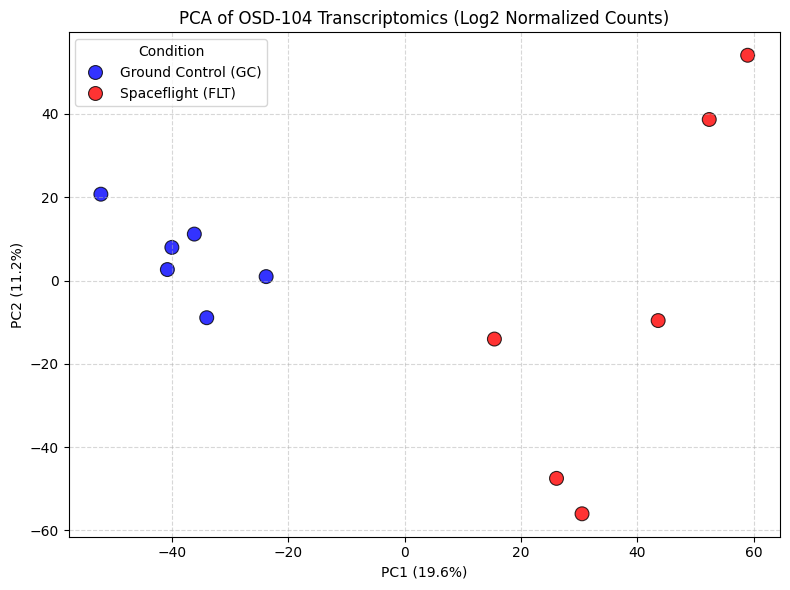

2026-08-29 21:10:15,104 - INFO - PCA plot saved: AstroLongevity_Data_Final\PCA_OSD-104.png


In [6]:
# Cell 6: PCA of OSD-104 spaceflight vs ground control transcriptomics
#
# Uses the normalized expression columns from the NASA files.
# We apply a log2(x + 1) pseudocount transformation for variance stabilization before PCA.

if "OSD-104" not in dataframes:
    raise RuntimeError("OSD-104 data not loaded. Run Cell 3 first.")

df104 = dataframes["OSD-104"]

stat_keywords = {
    "Stat", "P.value", "Adj.p.value", "Log2fc", "LRT", "Average_Log2fc",
    "Group.Mean", "Group.Stdev", "ENSEMBL", "SYMBOL", "GENENAME", "All.mean", "All.stdev", "Unnamed"
}

sample_cols = []
for c in df104.columns:
    is_stat = any(kw.lower() in c.lower() for kw in stat_keywords)
    is_numeric = pd.api.types.is_numeric_dtype(df104[c])
    if is_numeric and not is_stat and ("FLT" in c.upper() or "GC" in c.upper()) and "_de" not in c.lower():
        sample_cols.append(c)

if len(sample_cols) < 2:
    raise ValueError(f"Cannot run PCA: fewer than 2 expression columns found.\nAll columns: {list(df104.columns)}")

logger.info(f"Sample columns selected for PCA: {sample_cols}")

gene_col = "SYMBOL" if "SYMBOL" in df104.columns else df104.columns[0]
expr_matrix = df104.set_index(gene_col)[sample_cols].dropna()

# Apply log2(x + 1) transform for variance stabilization
log_matrix = np.log2(expr_matrix + 1)
log_matrix.index = log_matrix.index.astype(str)

pca = PCA(n_components=2)
pcs = pca.fit_transform(log_matrix.T.values)

evr1 = pca.explained_variance_ratio_[0] * 100
evr2 = pca.explained_variance_ratio_[1] * 100
logger.info(f"PCA complete: PC1={evr1:.1f}%, PC2={evr2:.1f}%")

conditions = []
for col in sample_cols:
    if "FLT" in col.upper():
        conditions.append("Spaceflight (FLT)")
    elif "GC" in col.upper():
        conditions.append("Ground Control (GC)")
    else:
        conditions.append("Unknown")

pca_df = pd.DataFrame({
    "PC1": pcs[:, 0],
    "PC2": pcs[:, 1],
    "Sample": sample_cols,
    "Condition": conditions
})

print(f"\nPC1 explained variance : {evr1:.1f}%")
print(f"PC2 explained variance : {evr2:.1f}%")
print(f"Total (PC1+PC2)        : {evr1+evr2:.1f}%")
print(f"Samples analyzed       : {len(pca_df)}")
print(pca_df.to_string(index=False))

# Plot PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="Condition",
    palette={"Spaceflight (FLT)": "red", "Ground Control (GC)": "blue"},
    s=100, edgecolor="black", alpha=0.8
)
plt.title("PCA of OSD-104 Transcriptomics (Log2 Normalized Counts)")
plt.xlabel(f"PC1 ({evr1:.1f}%)")
plt.ylabel(f"PC2 ({evr2:.1f}%)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Condition")
plt.tight_layout()
pca_plot_path = os.path.join(DRIVE_PATH, "PCA_OSD-104.png")
plt.savefig(pca_plot_path, dpi=300)
plt.show()
logger.info(f"PCA plot saved: {pca_plot_path}")



In [7]:
# Cell 7: Cross-study concordance analysis
#
# Identifies genes that are significantly and directionally concordantly dysregulated
# across OSD-101 and OSD-104 (both RNA-Seq DE datasets).
#
# OSD-21 is a microarray dataset and uses a different statistical framework
# (RMA normalized intensities, not DESeq2 p-values). Including it in intersection
# requires a separate limma differential expression step which is beyond the
# scope of this pipeline. OSD-21 is retained in the dataframes dictionary
# for downstream use.
#
# The concordance criterion:
#   1. Gene must be significant (adj. p < 0.05) in both OSD-101 and OSD-104
#   2. Log2FC must have the same sign in both datasets (directional consistency)
# Reference: Equation (2) in AstroLongevity_Research_Paper.tex

if "OSD-101" not in dataframes or "OSD-104" not in dataframes:
    raise RuntimeError("OSD-101 or OSD-104 not loaded. Run Cell 3 first.")

df101 = dataframes["OSD-101"].copy()
df104 = dataframes["OSD-104"].copy()

# Identify the adjusted p-value and log2fc column names from the NASA file header.
# NASA GLbulkRNAseq pipeline uses a consistent naming pattern.
def find_col(df, patterns):
    """Return the first column name that contains all patterns (case-insensitive)."""
    for col in df.columns:
        if all(p.lower() in col.lower() for p in patterns):
            return col
    return None

# OSD-101 columns
pval_col_101 = find_col(df101, ["Adj.p.value"])
log2_col_101 = find_col(df101, ["Log2fc"])
print(f"OSD-101 adj p-value column : {pval_col_101}")
print(f"OSD-101 log2fc column      : {log2_col_101}")

# OSD-104 columns
pval_col_104 = find_col(df104, ["Adj.p.value"])
log2_col_104 = find_col(df104, ["Log2fc"])
print(f"OSD-104 adj p-value column : {pval_col_104}")
print(f"OSD-104 log2fc column      : {log2_col_104}")

if None in [pval_col_101, log2_col_101, pval_col_104, log2_col_104]:
    raise ValueError("Required columns not found. Check NASA file column names above.")

# Drop rows with null SYMBOL or null p-value or null log2fc
df101 = df101.dropna(subset=["SYMBOL", pval_col_101, log2_col_101]).copy()
df104 = df104.dropna(subset=["SYMBOL", pval_col_104, log2_col_104]).copy()

# Significance filter (adj. p < 0.05)
P_THRESH = 0.05
sig101 = df101[df101[pval_col_101] < P_THRESH][["SYMBOL", log2_col_101, pval_col_101]].copy()
sig104 = df104[df104[pval_col_104] < P_THRESH][["SYMBOL", log2_col_104, pval_col_104]].copy()

print(f"\nSignificant genes (adj.p < {P_THRESH}):")
print(f"  OSD-101 : {len(sig101)}")
print(f"  OSD-104 : {len(sig104)}")

# Jaccard similarity of significant gene sets
set101 = set(sig101["SYMBOL"].str.upper())
set104 = set(sig104["SYMBOL"].str.upper())
jaccard = len(set101 & set104) / len(set101 | set104) if (set101 | set104) else 0
print(f"  Jaccard similarity : {jaccard:.4f}")

# Inner join on SYMBOL to get intersection
merged = pd.merge(
    sig101.rename(columns={log2_col_101: "Log2fc_101", pval_col_101: "Adj.p.value_101"}),
    sig104.rename(columns={log2_col_104: "Log2fc_104", pval_col_104: "Adj.p.value_104"}),
    on="SYMBOL"
)
print(f"  Intersection size  : {len(merged)}")

# Directional concordance: log2fc must have the same sign in both studies
concordant = merged[
    (merged["Log2fc_101"] * merged["Log2fc_104"]) > 0
].copy()
print(f"  Directionally concordant : {len(concordant)}")

# Average log2fc across the two studies for ranking
concordant["Average_Log2fc"] = (concordant["Log2fc_101"] + concordant["Log2fc_104"]) / 2

# Final signature table
final_sig = concordant[
    ["SYMBOL", "Average_Log2fc", "Adj.p.value_101", "Adj.p.value_104", "Log2fc_101", "Log2fc_104"]
].sort_values(by="Average_Log2fc", ascending=False).reset_index(drop=True)

print(f"\nTop 10 upregulated concordant genes:")
print(final_sig.head(10).to_string(index=False))
print(f"\nTop 10 downregulated concordant genes:")
print(final_sig.tail(10).to_string(index=False))

# Save
sig_path = os.path.join(DRIVE_PATH, "Concordant_Atrophy_Signature.csv")
final_sig.to_csv(sig_path, index=False)
logger.info(f"Concordant atrophy signature saved: {sig_path}")
print(f"\nSignature saved to Drive: {sig_path}")
print(f"Total concordant genes in signature: {len(final_sig)}")

OSD-101 adj p-value column : Adj.p.value_(Ground Control)v(Space Flight)
OSD-101 log2fc column      : Log2fc_(Ground Control)v(Space Flight)
OSD-104 adj p-value column : Adj.p.value_(Ground Control)v(Space Flight)
OSD-104 log2fc column      : Log2fc_(Ground Control)v(Space Flight)

Significant genes (adj.p < 0.05):
  OSD-101 : 225
  OSD-104 : 4603
  Jaccard similarity : 0.0310
  Intersection size  : 147
  Directionally concordant : 141

Top 10 upregulated concordant genes:
  SYMBOL  Average_Log2fc  Adj.p.value_101  Adj.p.value_104  Log2fc_101  Log2fc_104
   Ciart        2.193674     1.218056e-03     3.961604e-23    1.475584    2.911764
  Gm5532        1.849773     2.488795e-02     5.221749e-99    1.634508    2.065039
     Dbp        1.691330     7.039157e-04     3.374902e-06    1.674102    1.708558
  Apold1        1.611423     1.934330e-03     9.357359e-10    1.110378    2.112467
     Arc        1.527879     4.404212e-02     4.737349e-15    1.160233    1.895524
Serpine1        1.348504


Signature saved to Drive: AstroLongevity_Data_Final\Concordant_Atrophy_Signature.csv
Total concordant genes in signature: 141
